In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Loading and Exploring the Dataset

df = pd.read_csv('stocks.csv')

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")

Dataset loaded successfully!
Dataset shape: (248, 8)


In [3]:
# Displaying basic information
print("\nDataset Info:")
print(df.info())

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Description:")
print(df.describe())

print("\nNo. of null values in dataset:")
print(df.isna().sum())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Ticker     248 non-null    object 
 1   Date       248 non-null    object 
 2   Open       248 non-null    float64
 3   High       248 non-null    float64
 4   Low        248 non-null    float64
 5   Close      248 non-null    float64
 6   Adj Close  248 non-null    float64
 7   Volume     248 non-null    int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 15.6+ KB
None

First 5 rows:
  Ticker       Date        Open        High         Low       Close  \
0   AAPL   2-7-2023  150.639999  155.229996  150.639999  154.649994   
1   AAPL   2-8-2023  153.880005  154.580002  151.169998  151.919998   
2   AAPL   2-9-2023  153.779999  154.330002  150.419998  150.869995   
3   AAPL  2-10-2023  149.460007  151.339996  149.220001  151.009995   
4   AAPL  2-13-2023  150.949997  154.259995

In [4]:
# Data Preprocessing

# Convert Date to datetime format
df['Date'] = pd.to_datetime(df['Date'])
df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

# Feature Creation
df['Price_Range'] = df['High'] - df['Low']
df['Price_Change'] = df['Close'] - df['Open']
df['Price_Change_Percent'] = (df['Price_Change'] / df['Open']) * 100
df['Volume_Change'] = df['Volume'].pct_change()
df['Daily_Return'] = df['Close'].pct_change()

print("\nNew features created:")
print(df[['Price_Range', 'Price_Change', 'Price_Change_Percent', 'Daily_Return', 'Volume_Change']].head())


New features created:
   Price_Range  Price_Change  Price_Change_Percent  Daily_Return  \
0     4.589996      4.009995              2.661972           NaN   
1     3.410004     -1.960007             -1.273724     -0.017653   
2     3.910004     -2.910004             -1.892316     -0.006912   
3     2.119995      1.549988              1.037059      0.000928   
4     3.339996      2.900009              1.921172      0.018807   

   Volume_Change  
0            NaN  
1      -0.230460  
2      -0.126528  
3       0.025775  
4       0.082650  


In [5]:
# Exploratory Data Analysis

AAPL = df[df['Ticker'] == 'AAPL']
MSFT = df[df['Ticker'] == 'MSFT']
NFLX = df[df['Ticker'] == 'NFLX']
GOOG = df[df['Ticker'] == 'GOOG']

print("\nAAPL dataset:")
print(AAPL.head())

print("\nMSFT dataset:")
print(MSFT.head())

print("\nNFLX dataset:")
print(NFLX.head())

print("\nGOOG dataset:")
print(GOOG.head())


AAPL dataset:
  Ticker       Date        Open        High         Low       Close  \
0   AAPL 2023-02-07  150.639999  155.229996  150.639999  154.649994   
1   AAPL 2023-02-08  153.880005  154.580002  151.169998  151.919998   
2   AAPL 2023-02-09  153.779999  154.330002  150.419998  150.869995   
3   AAPL 2023-02-10  149.460007  151.339996  149.220001  151.009995   
4   AAPL 2023-02-13  150.949997  154.259995  150.919998  153.850006   

    Adj Close    Volume  Day  Month  Year  Price_Range  Price_Change  \
0  154.414230  83322600    7      2  2023     4.589996      4.009995   
1  151.688400  64120100    8      2  2023     3.410004     -1.960007   
2  150.639999  56007100    9      2  2023     3.910004     -2.910004   
3  151.009995  57450700   10      2  2023     2.119995      1.549988   
4  153.850006  62199000   13      2  2023     3.339996      2.900009   

   Price_Change_Percent  Volume_Change  Daily_Return  
0              2.661972            NaN           NaN  
1             -

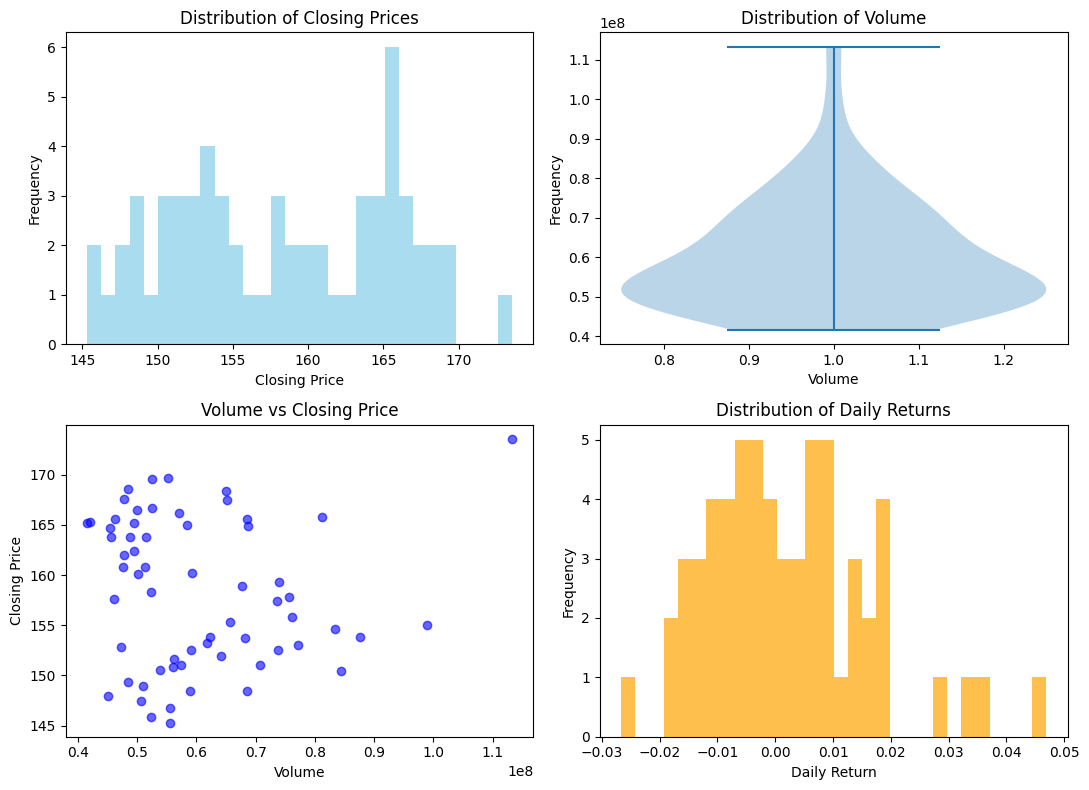

In [6]:
# AAPL stock analysis
plt.figure(figsize=(11, 8))

plt.subplot(2, 2, 1)
plt.hist(AAPL['Close'], bins=30, alpha=0.7, color='skyblue')
plt.title('Distribution of Closing Prices')
plt.xlabel('Closing Price')
plt.ylabel('Frequency')

plt.subplot(2, 2, 2)
plt.violinplot(AAPL['Volume'])
plt.title('Distribution of Volume')
plt.xlabel('Volume')
plt.ylabel('Frequency')

plt.subplot(2, 2, 3)
plt.scatter(AAPL['Volume'], AAPL['Close'], alpha=0.6, color='blue')
plt.title('Volume vs Closing Price')
plt.xlabel('Volume')
plt.ylabel('Closing Price')

plt.subplot(2, 2, 4)
plt.hist(AAPL['Daily_Return'].dropna(), bins=30, alpha=0.7, color='orange')
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

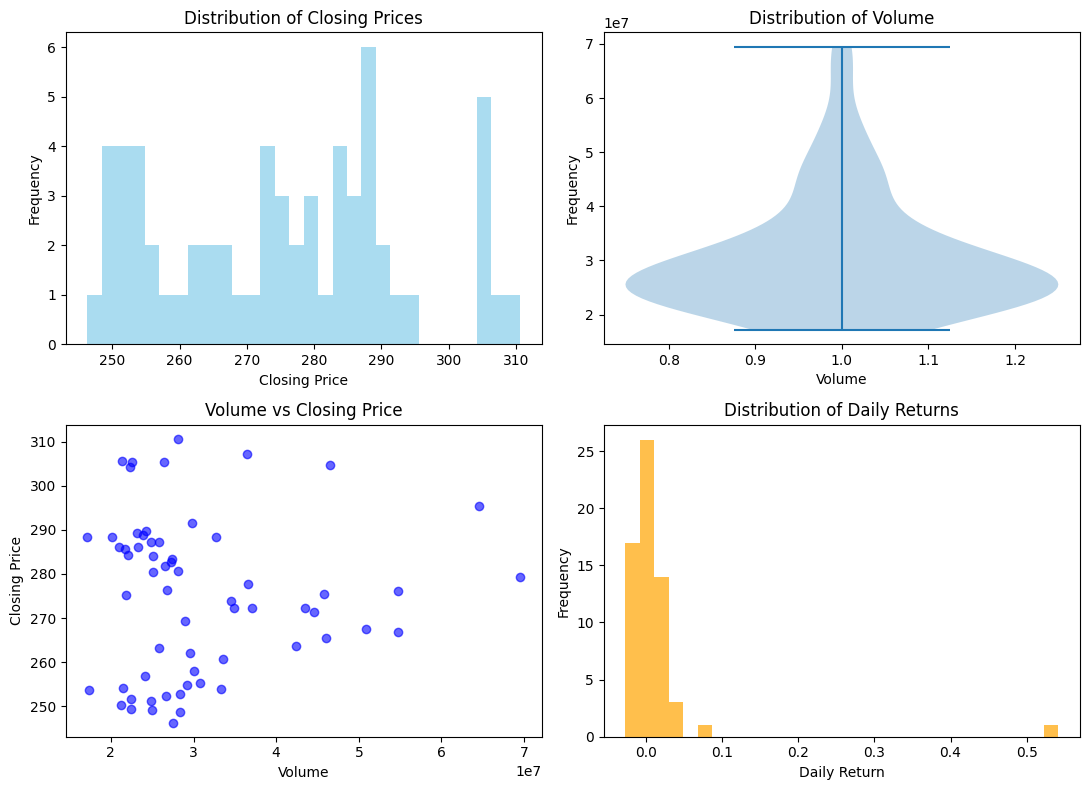

In [7]:
# MSFT stock analysis

plt.figure(figsize=(11, 8))

plt.subplot(2, 2, 1)
plt.hist(MSFT['Close'], bins=30, alpha=0.7, color='skyblue')
plt.title('Distribution of Closing Prices')
plt.xlabel('Closing Price')
plt.ylabel('Frequency')

plt.subplot(2, 2, 2)
plt.violinplot(MSFT['Volume'])
plt.title('Distribution of Volume')
plt.xlabel('Volume')
plt.ylabel('Frequency')

plt.subplot(2, 2, 3)
plt.scatter(MSFT['Volume'], MSFT['Close'], alpha=0.6, color='blue')
plt.title('Volume vs Closing Price')
plt.xlabel('Volume')
plt.ylabel('Closing Price')

plt.subplot(2, 2, 4)
plt.hist(MSFT['Daily_Return'].dropna(), bins=30, alpha=0.7, color='orange')
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

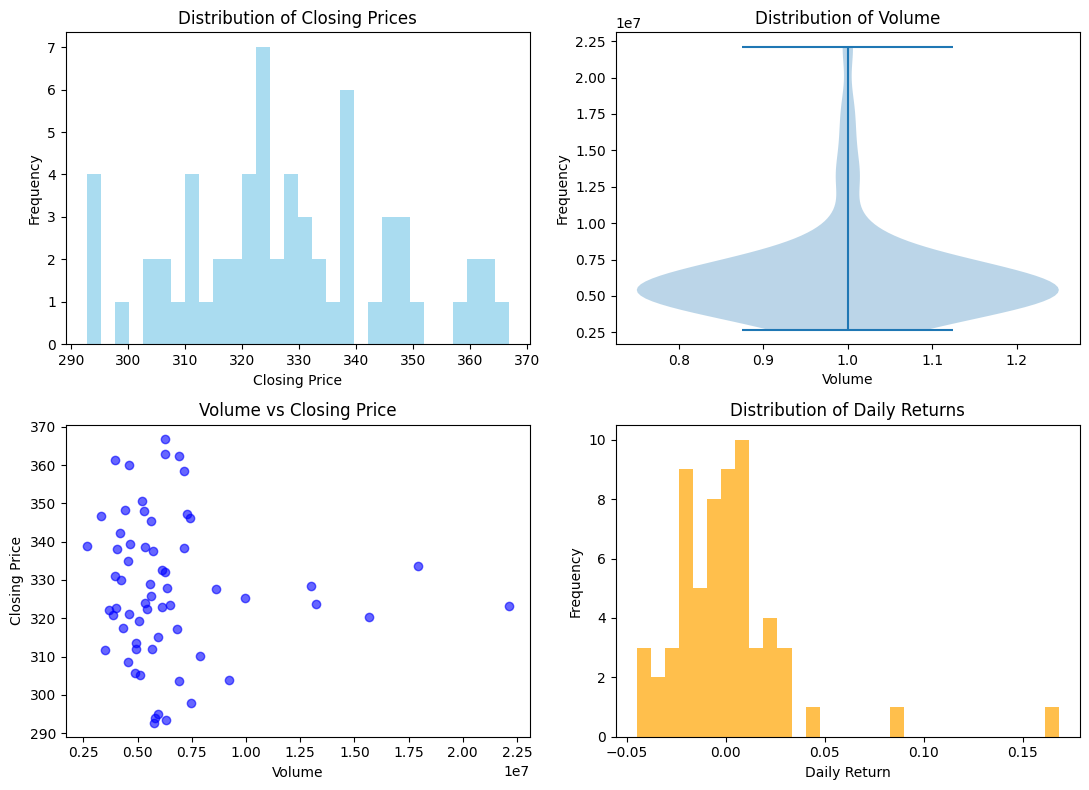

In [8]:
# NFLX stock analysis
plt.figure(figsize=(11, 8))

plt.subplot(2, 2, 1)
plt.hist(NFLX['Close'], bins=30, alpha=0.7, color='skyblue')
plt.title('Distribution of Closing Prices')
plt.xlabel('Closing Price')
plt.ylabel('Frequency')

plt.subplot(2, 2, 2)
plt.violinplot(NFLX['Volume'])
plt.title('Distribution of Volume')
plt.xlabel('Volume')
plt.ylabel('Frequency')

plt.subplot(2, 2, 3)
plt.scatter(NFLX['Volume'], NFLX['Close'], alpha=0.6, color='blue')
plt.title('Volume vs Closing Price')
plt.xlabel('Volume')
plt.ylabel('Closing Price')

plt.subplot(2, 2, 4)
plt.hist(NFLX['Daily_Return'].dropna(), bins=30, alpha=0.7, color='orange')
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

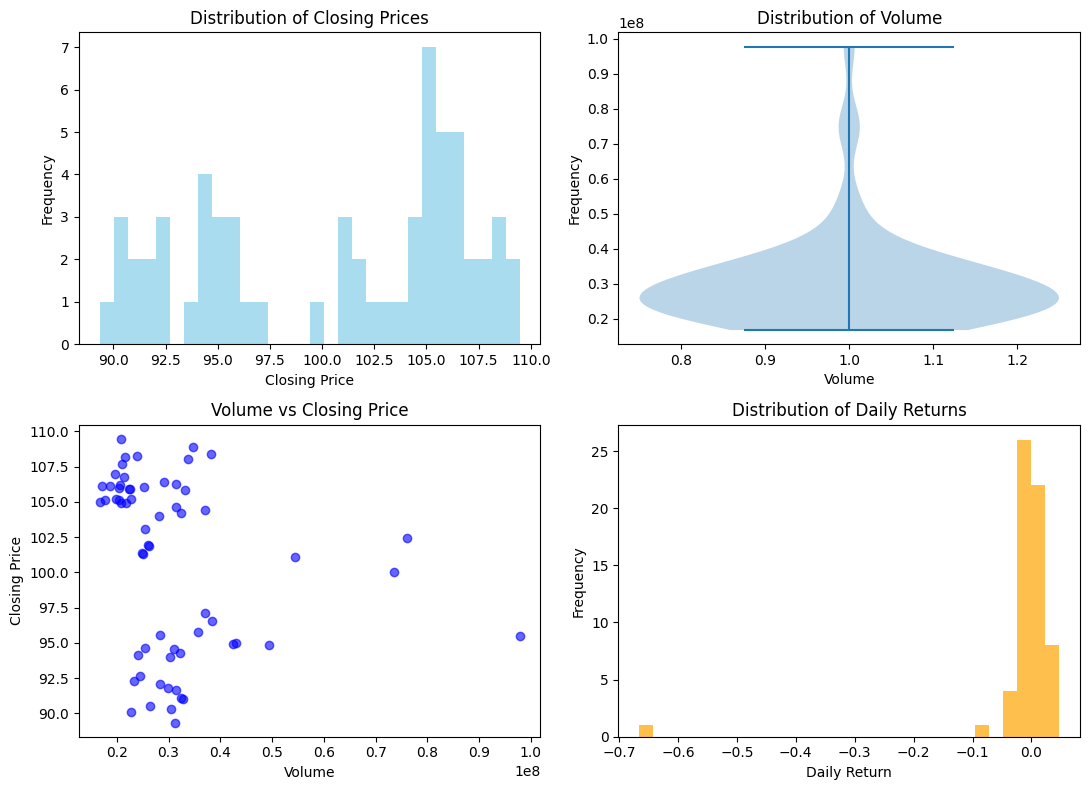

In [9]:
# GOOG stock analysis
plt.figure(figsize=(11, 8))

plt.subplot(2, 2, 1)
plt.hist(GOOG['Close'], bins=30, alpha=0.7, color='skyblue')
plt.title('Distribution of Closing Prices')
plt.xlabel('Closing Price')
plt.ylabel('Frequency')

plt.subplot(2, 2, 2)
plt.violinplot(GOOG['Volume'])
plt.title('Distribution of Volume')
plt.xlabel('Volume')
plt.ylabel('Frequency')

plt.subplot(2, 2, 3)
plt.scatter(GOOG['Volume'], GOOG['Close'], alpha=0.6, color='blue')
plt.title('Volume vs Closing Price')
plt.xlabel('Volume')
plt.ylabel('Closing Price')

plt.subplot(2, 2, 4)
plt.hist(GOOG['Daily_Return'].dropna(), bins=30, alpha=0.7, color='orange')
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

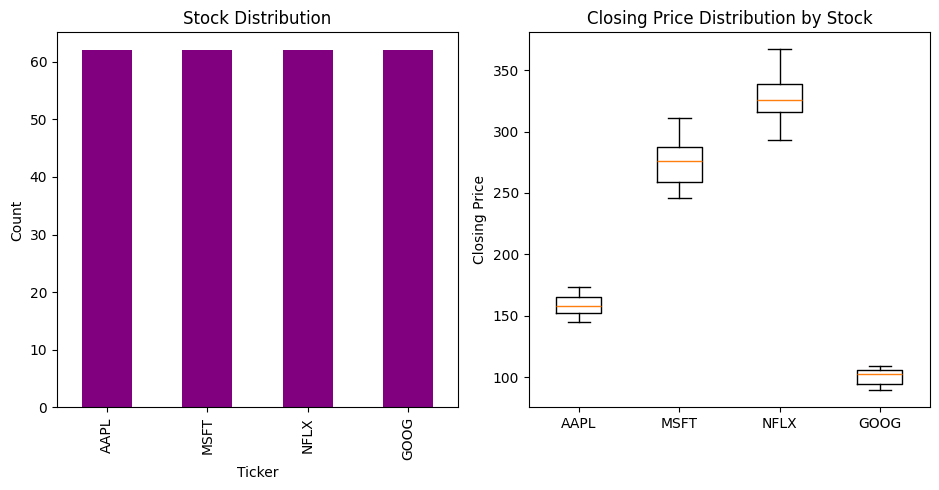

In [10]:
# Inter-stock comparison
plt.figure(figsize=(9.5, 5))

plt.subplot(1, 2, 1)
df['Ticker'].value_counts().plot(kind='bar', color='purple')
plt.title('Stock Distribution')
plt.xlabel('Ticker')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
plt.boxplot([df[df['Ticker'] == stock]['Close'] for stock in df['Ticker'].unique()])
plt.xticks(range(1, len(df['Ticker'].unique()) + 1), df['Ticker'].unique())
plt.title('Closing Price Distribution by Stock')
plt.ylabel('Closing Price')

plt.tight_layout()
plt.show()

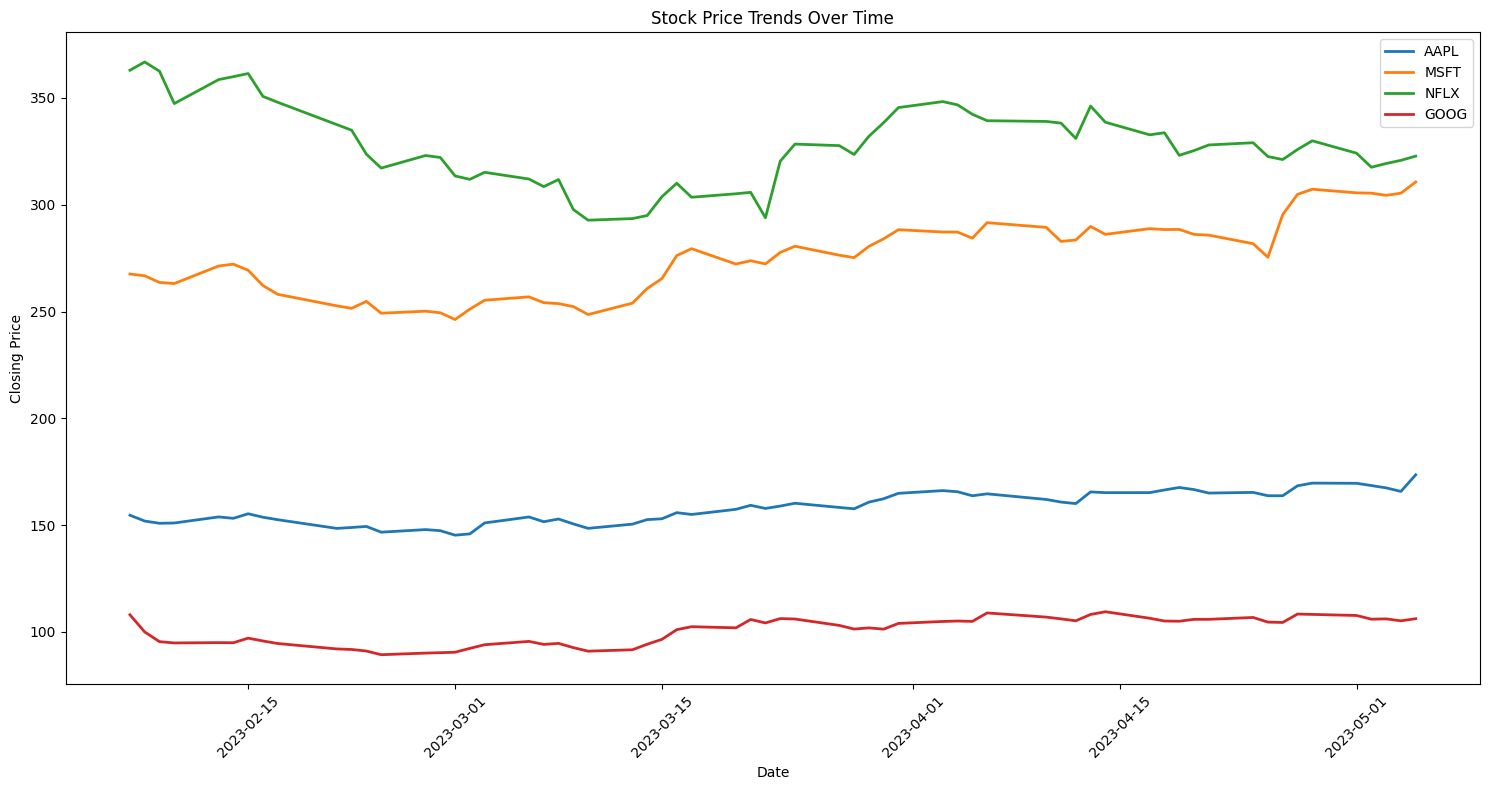

In [11]:
# Price trends over time for each stock
plt.figure(figsize=(15, 8))
for stock in df['Ticker'].unique():
    stock_data = df[df['Ticker'] == stock]
    plt.plot(stock_data['Date'], stock_data['Close'], label=stock, linewidth=2)

plt.title('Stock Price Trends Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

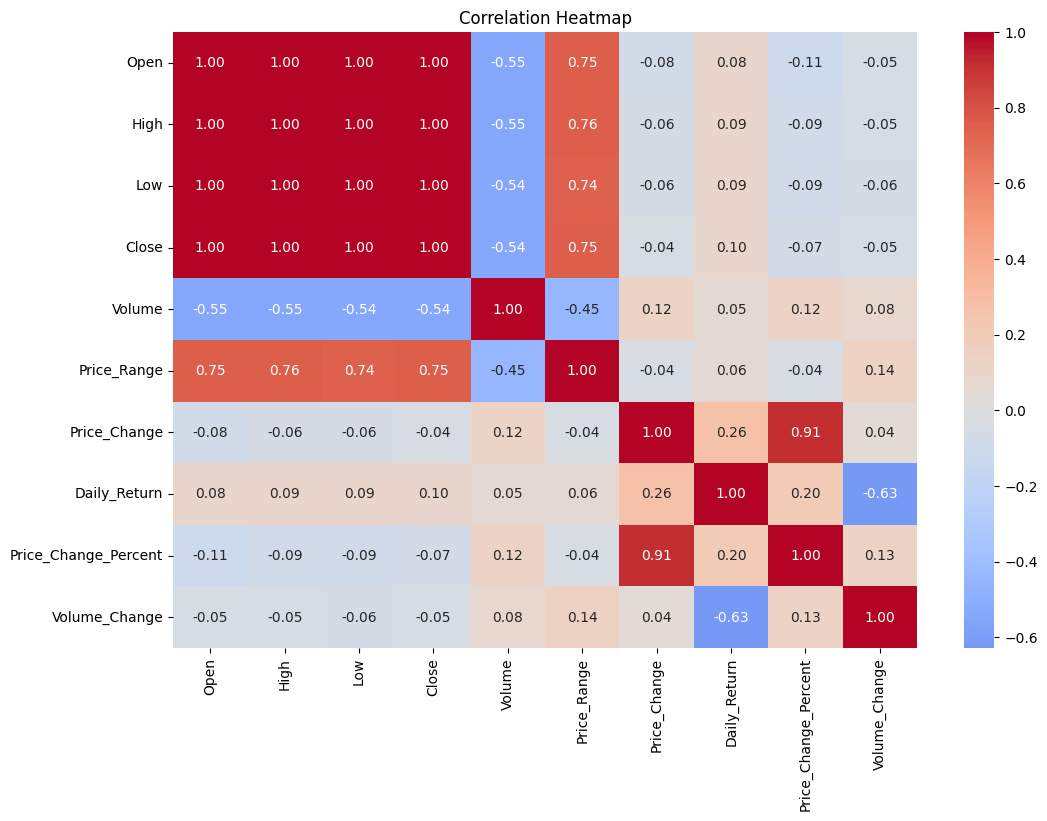

In [12]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
numeric_columns = ['Open', 'High', 'Low', 'Close', 'Volume', 'Price_Range', 
                  'Price_Change', 'Daily_Return', 'Price_Change_Percent', 'Volume_Change']
correlation_matrix = df[numeric_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [13]:
# Stock-wise statistics

stocks = [AAPL, MSFT, NFLX, GOOG]
stock_names = ['AAPL', 'MSFT', 'NFLX', 'GOOG']

stock_stats = pd.DataFrame({
    'Stocks' : stock_names,
    'Close_Mean': [stock['Close'].mean() for stock in stocks],
    'Close_Median': [stock['Close'].median() for stock in stocks],
    'Close_Std_Dev': [stock['Close'].std() for stock in stocks],
    'Volume_Mean': [stock['Volume'].mean() for stock in stocks],
    'Volume_Median': [stock['Volume'].median() for stock in stocks],
    'Volume_Std_Dev': [stock['Volume'].std() for stock in stocks],
    'Daily_Return_Mean': [stock['Daily_Return'].mean() for stock in stocks],
    'Daily_Return_Median': [stock['Daily_Return'].median() for stock in stocks],
    'Price_Range': [f"{stock['Price_Range'].min()} - {stock['Price_Range'].max()}" for stock in stocks],
})
stock_stats.set_index('Stocks', inplace=True)

print("Stock-wise Statistics:")
print(stock_stats)

Stock-wise Statistics:
        Close_Mean  Close_Median  Close_Std_Dev   Volume_Mean  Volume_Median  \
Stocks                                                                         
AAPL    158.240645    158.055000       7.360485  6.028296e+07     56094550.0   
MSFT    275.039839    275.810013      17.676231  3.084835e+07     27340000.0   
NFLX    327.614677    325.600006      18.554419  6.471732e+06      5639750.0   
GOOG    100.631532    102.759998       6.279464  3.072537e+07     27205200.0   

        Volume_Std_Dev  Daily_Return_Mean  Daily_Return_Median  \
Stocks                                                           
AAPL      1.430605e+07           0.001991             0.000121   
MSFT      1.109188e+07           0.011298            -0.000857   
NFLX      3.416398e+06           0.001066            -0.001612   
GOOG      1.422509e+07          -0.010796            -0.001168   

                                   Price_Range  
Stocks                                          
A

In [14]:
# Volatility Calculation (Volatility = (std_dev /(max - min)) * 100)

std_dr = {f'{stock}': stock['Daily_Return'].std() for stock in stocks}
min_dr = {f'{stock}': stock['Daily_Return'].min() for stock in stocks}
max_dr = {f'{stock}': stock['Daily_Return'].max() for stock in stocks}

volatility = pd.DataFrame({
    "Stocks" : stock_names,
    "Volatility %" : [(std_dr[f"{stock}"] / (max_dr[f"{stock}"] - min_dr[f"{stock}"])) * 100 for stock in stocks]
    })

print("\nStock Volatility (Higher = More Volatile):")
print(volatility.sort_values(ascending=False, by='Volatility %').round(4))


Stock Volatility (Higher = More Volatile):
  Stocks  Volatility %
0   AAPL       19.2268
2   NFLX       14.5526
1   MSFT       12.4445
3   GOOG       12.2095


In [15]:
# Numerically encoding Ticker field
df['Ticker_encoded'] = pd.factorize(df['Ticker'])[0]

# Selectng features for prediction based on Correlation Heatmap
features = ['Open', 'High', 'Low', 'Volume', 'Price_Range', 'Price_Change', 'Ticker_encoded', 'Day', 'Month']

X = df[features]
y = df['Close']

print(f"Features used: {features}")
print(f"X shape: {X.shape}, y shape: {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Features used: ['Open', 'High', 'Low', 'Volume', 'Price_Range', 'Price_Change', 'Ticker_encoded', 'Day', 'Month']
X shape: (248, 9), y shape: (248,)
Training set: (198, 9), Test set: (50, 9)


In [16]:
# Model 1: Random Forest Regressor
print("1. Random Forest Regressor")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print(f"Random Forest - MSE: {mse_rf:.2f}, R²: {r2_rf:.4f}, MAE: {mae_rf:.2f}")

# Model 2: Decision Tree Regressor
print("\n2. Decision Tree Regressor")
dt_model = DecisionTreeRegressor(random_state=42, max_depth=8)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)

mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)

print(f"Decision Tree - MSE: {mse_dt:.2f}, R²: {r2_dt:.4f}, MAE: {mae_dt:.2f}")

1. Random Forest Regressor
Random Forest - MSE: 4.00, R²: 0.9995, MAE: 1.51

2. Decision Tree Regressor
Decision Tree - MSE: 7.18, R²: 0.9991, MAE: 2.04


In [17]:
# Comparing the 2 models
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Decision Tree'],
    'MSE': [mse_rf, mse_dt],
    'R²': [r2_rf, r2_dt],
    'MAE': [mae_rf, mae_dt]
})

print("\nModel Comparison:")
print(comparison)


Model Comparison:
           Model       MSE        R²       MAE
0  Random Forest  4.003731  0.999509  1.512158
1  Decision Tree  7.175932  0.999120  2.037977


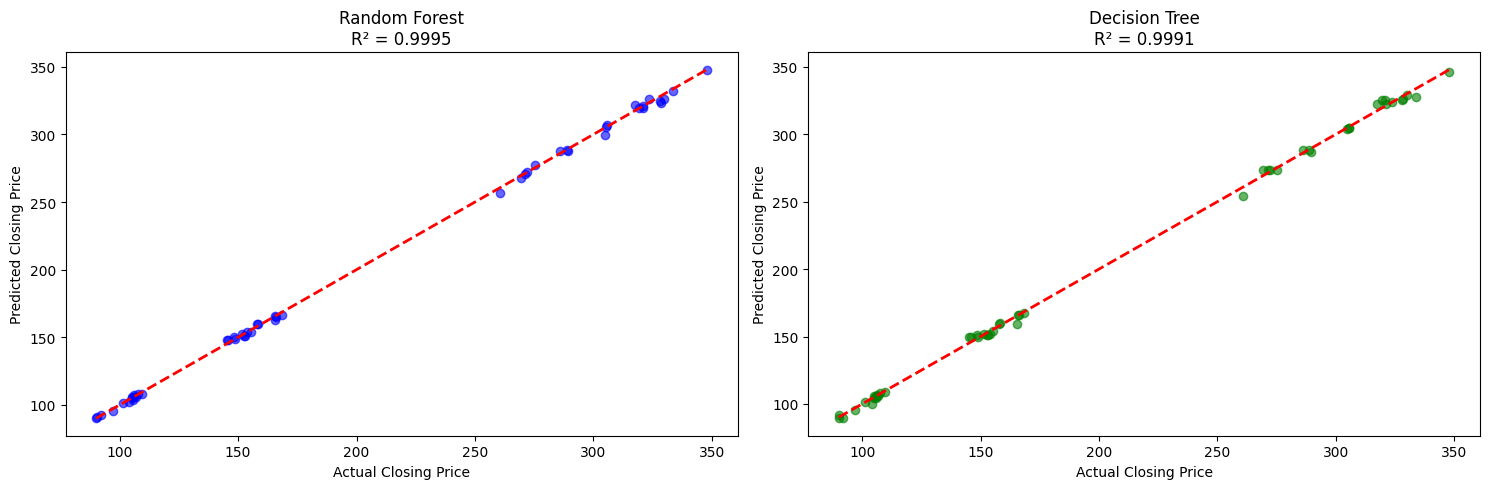

In [18]:
plt.figure(figsize=(15, 5))

# Actual vs Predicted for Random Forest
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_rf, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Closing Price')
plt.ylabel('Predicted Closing Price')
plt.title(f'Random Forest\nR² = {r2_rf:.4f}')

# Actual vs Predicted for Decision Tree
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_dt, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Closing Price')
plt.ylabel('Predicted Closing Price')
plt.title(f'Decision Tree\nR² = {r2_dt:.4f}')

plt.tight_layout()
plt.show()

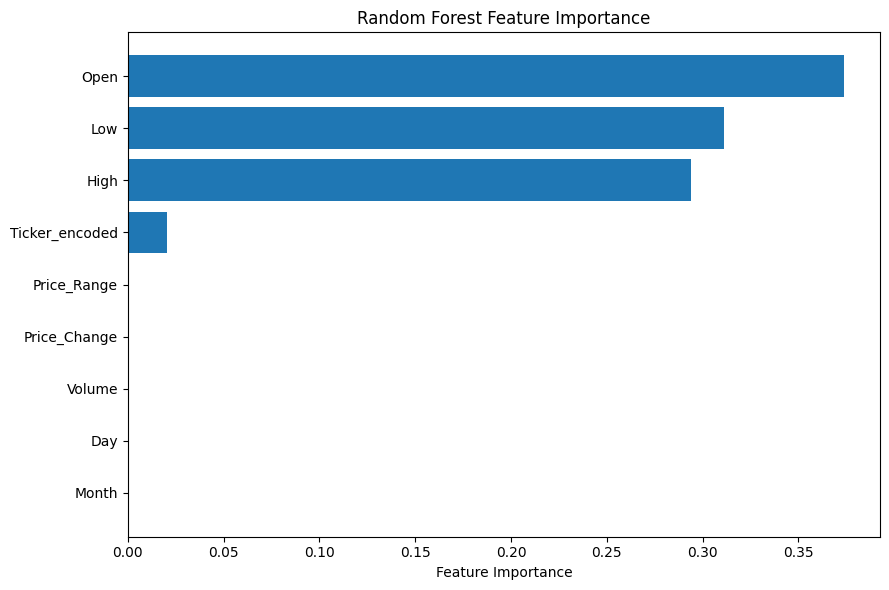

In [19]:
# Feature importance for Random Forest
plt.figure(figsize=(9, 6))
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True)

plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

In [20]:
# Making predictions on new sample data
sample_features = X.iloc[0:1]  # Taking first row as sample
sample_features_scaled = scaler.transform(sample_features)
sample_prediction_rf = rf_model.predict(sample_features_scaled)
sample_prediction_dt = dt_model.predict(sample_features_scaled)

print(f"Sample stock features:")
for feature in features:
    print(f"  {feature}: {sample_features[feature].values[0]}")
print(f"Random Forest prediction: ${sample_prediction_rf[0]:.2f}")
print(f"Decision Tree prediction: ${sample_prediction_dt[0]:.2f}")
print(f"Actual closing price: ${y.iloc[0]:.2f}")

Sample stock features:
  Open: 150.6399994
  High: 155.2299957
  Low: 150.6399994
  Volume: 83322600
  Price_Range: 4.589996299999996
  Price_Change: 4.009994500000005
  Ticker_encoded: 0
  Day: 7
  Month: 2
Random Forest prediction: $153.62
Decision Tree prediction: $154.65
Actual closing price: $154.65
